In [1]:
import model as m
from tensorflow.keras.models import load_model
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import Evaluate_results as er



2024-03-19 09:55:25.737537: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-03-19 09:55:25.759572: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-03-19 09:55:25.875567: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-19 09:55:25.875618: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-19 09:55:25.895300: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [2]:
from keras import backend as K
import tensorflow as tf
import tensorflow as tf



        

In [3]:
dataset_path = 'Data/trainign_dataset_51270_microarray_adjusted.csv'
loss = "mse"
optimizer = "adam"
metrics = ["mae"]
epochs = 1500
batch_size = 512
validation_split = 0.2
lasso_alpha = 0.01
two_step_normalization = True


In [4]:


training_data=pd.read_csv(dataset_path)
my_model = m.Model(training_data)
normalized_X_train, normalized_X_test_fs = my_model.prepare_data(df=training_data, lasso_alpha=lasso_alpha, two_step=two_step_normalization)
my_model.train(normalize_X_train=normalized_X_train, 
                epochs=epochs, optimizer=optimizer,
                loss=loss, metrics=metrics)



/tmp/ipykernel_199365/2431851691.py:1: DtypeWarning: Columns (51280) have mixed types. Specify dtype option on import or set low_memory=False.
  training_data=pd.read_csv(dataset_path)
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.736e+01, tolerance: 9.999e+00
  model = cd_fast.enet_coordinate_descent(
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MAE: 15.303
Loss: 313.782
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


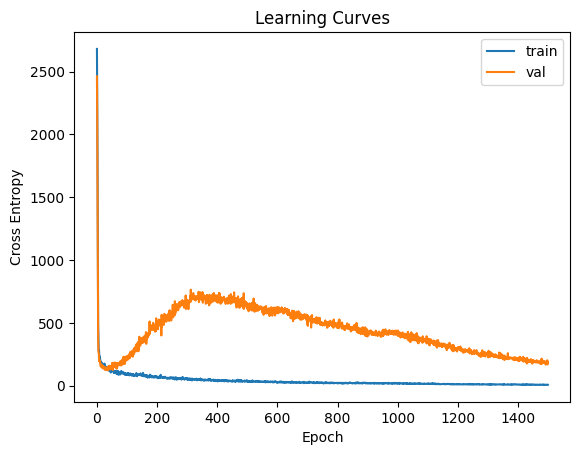

     Actual  Predicted Experiment
0     51.43  38.595448   GSE13070
1     34.20  50.292648    GSE8157
2     47.00  33.870777   GSE13070
3     39.00  35.513161   GSE47969
4     25.69  33.859970    GSE9103
..      ...        ...        ...
151   61.00  38.860298   GSE47969
152   54.15  38.681488   GSE13070
153   51.68  37.502251   GSE13070
154   46.00  23.661581   GSE48278
155   68.00  39.653915   GSE47969

[156 rows x 3 columns]


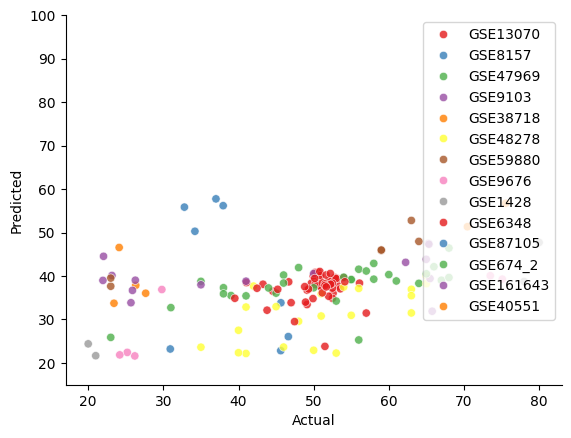

Experiment
GSE13070      50
GSE47969      29
GSE48278      21
GSE9103       12
GSE6348        7
GSE38718       6
GSE9676        6
GSE59880       6
GSE1428        4
GSE87105       4
GSE8157        4
GSE161643      3
GSE674_2       3
GSE40551       1
Name: count, dtype: int64
mae: 15.303424253219214, mse: 314.6844525033797, min: 21.622703552246094, max: 107.46110534667969
[313.78216552734375, 15.303422927856445]


In [5]:
m.plot_model(my_model.model, 'model.png', show_shapes=True)
results, error = my_model.test(normalized_X_test_fs, my_model.y_test)
m.print_performance(my_model.history, results, my_model.z_test)
print(error)

MAE: 10.129
Loss: 140.949
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


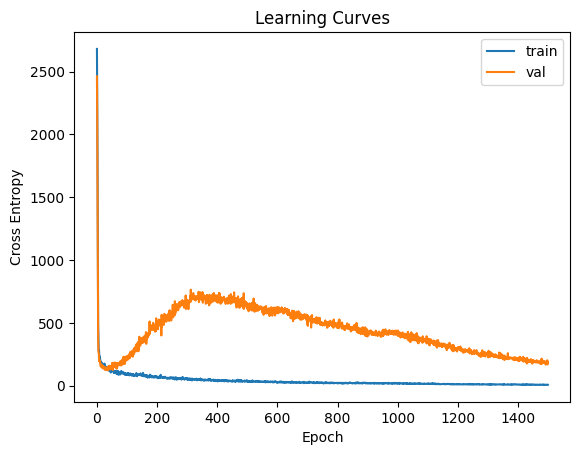

     Actual  Predicted Experiment
0     54.37  41.369114   GSE13070
1     46.00  38.771622   GSE47969
2     42.00  37.216476   GSE40551
3     44.83  38.071808   GSE13070
4     71.20  49.316051    GSE9676
..      ...        ...        ...
616   28.00  22.078413   GSE59880
617   76.09  48.385429   GSE87105
618   41.00  36.575314   GSE48278
619   53.00  38.409889   GSE48278
620   52.49  40.607677   GSE13070

[621 rows x 3 columns]


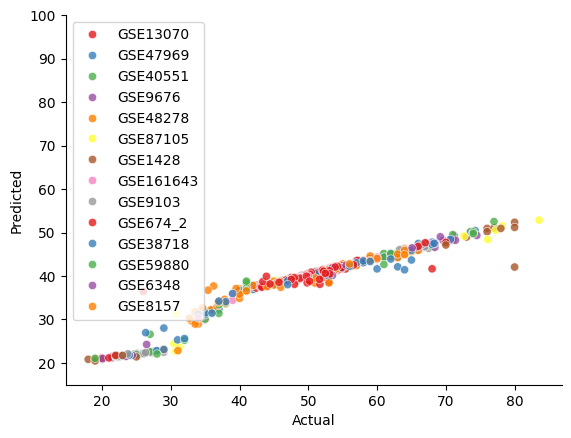

Experiment
GSE13070      230
GSE47969       96
GSE48278       93
GSE9103        28
GSE59880       24
GSE9676        24
GSE161643      21
GSE8157        19
GSE1428        18
GSE38718       16
GSE40551       15
GSE6348        13
GSE674_2       12
GSE87105       12
Name: count, dtype: int64
mae: 10.129096844069624, mse: 138.653130836486, min: 20.48043441772461, max: 52.86084747314453


In [6]:
results, error = my_model.test(normalized_X_train, my_model.y_train)
m.print_performance(my_model.history, results, my_model.z_train)

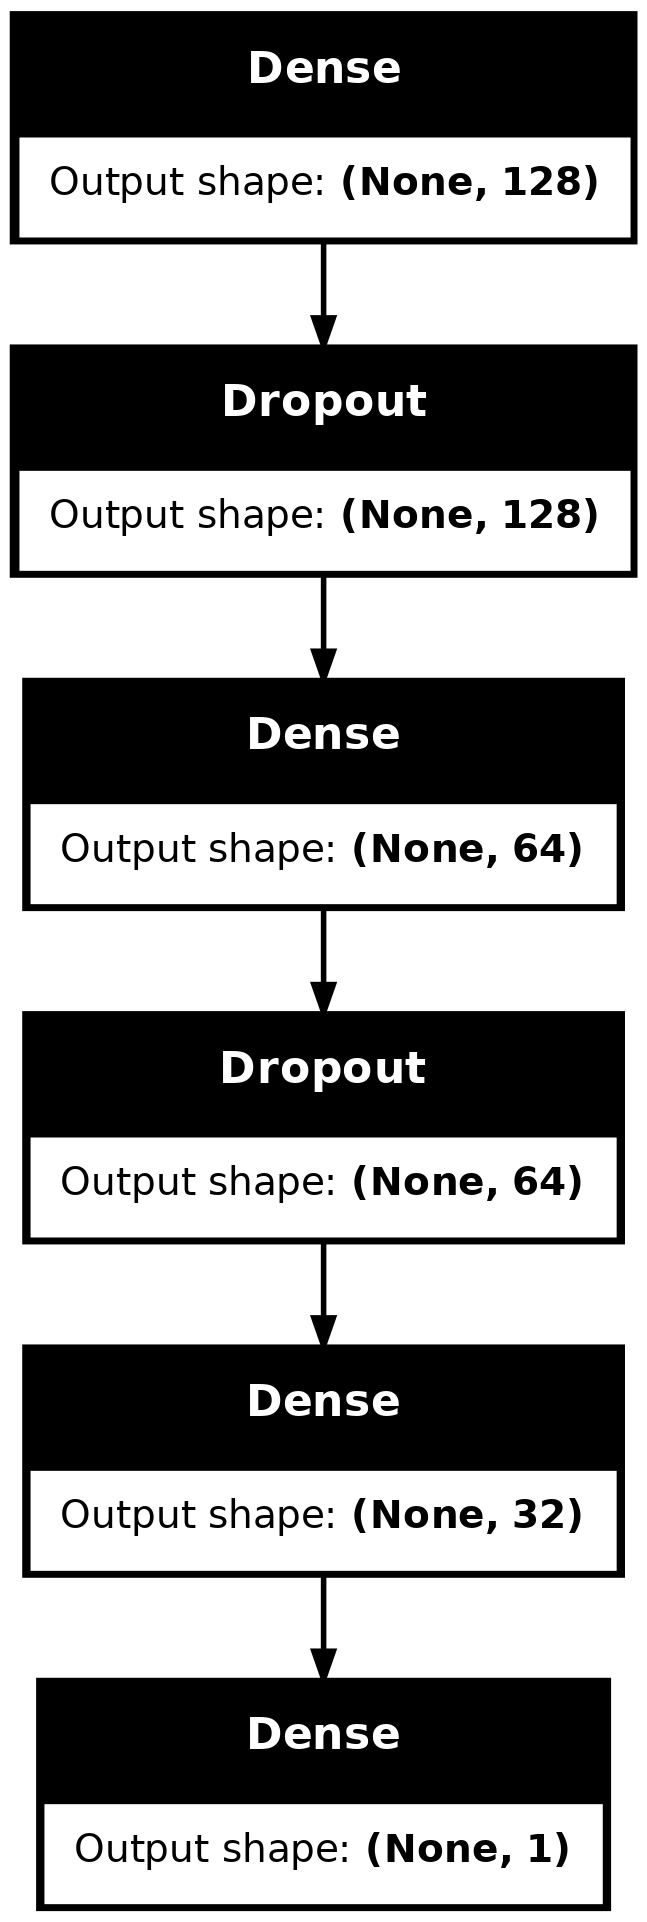

In [7]:
m.plot_model(my_model.model, 'model.png', show_shapes=True)


Lets try with one step normalization

In [20]:
two_step_normalization = False

In [21]:

training_data=pd.read_csv(dataset_path)
my_model = m.Model(training_data)
normalized_X_train, normalized_X_test_fs = my_model.prepare_data(df=training_data, lasso_alpha=lasso_alpha, two_step=two_step_normalization)
my_model.train(normalize_X_train=normalized_X_train, 
                epochs=epochs, optimizer=optimizer,
                loss=loss, metrics=metrics)

/tmp/ipykernel_199365/2645726252.py:1: DtypeWarning: Columns (51280) have mixed types. Specify dtype option on import or set low_memory=False.
  training_data=pd.read_csv(dataset_path)
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.198e+01, tolerance: 9.999e+00
  model = cd_fast.enet_coordinate_descent(


MAE: 14.132
Loss: 275.946
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


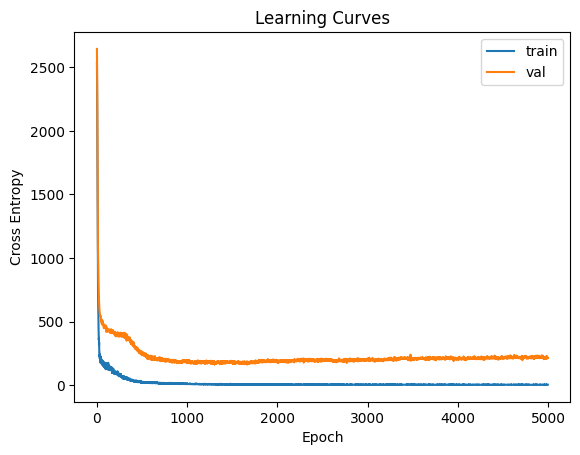

     Actual  Predicted Experiment
0     51.43  37.688618   GSE13070
1     34.20  47.499012    GSE8157
2     47.00  33.840378   GSE13070
3     39.00  42.629330   GSE47969
4     25.69  39.811573    GSE9103
..      ...        ...        ...
151   61.00  33.854031   GSE47969
152   54.15  41.504150   GSE13070
153   51.68  41.633038   GSE13070
154   46.00  33.306808   GSE48278
155   68.00  35.569592   GSE47969

[156 rows x 3 columns]


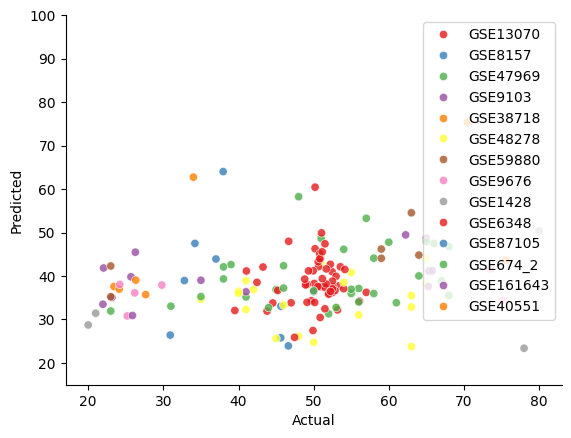

Experiment
GSE13070      50
GSE47969      29
GSE48278      21
GSE9103       12
GSE6348        7
GSE38718       6
GSE9676        6
GSE59880       6
GSE1428        4
GSE87105       4
GSE8157        4
GSE161643      3
GSE674_2       3
GSE40551       1
Name: count, dtype: int64
mae: 14.131515122927153, mse: 276.40593213767653, min: 23.397218704223633, max: 75.36083221435547
[275.9460754394531, 14.131515502929688]


In [22]:
m.plot_model(my_model.model, 'model.png', show_shapes=True)
results, error = my_model.test(normalized_X_test_fs, my_model.y_test)
m.print_performance(my_model.history, results, my_model.z_test)
print(error)

MAE: 8.761
Loss: 105.887
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 604us/step


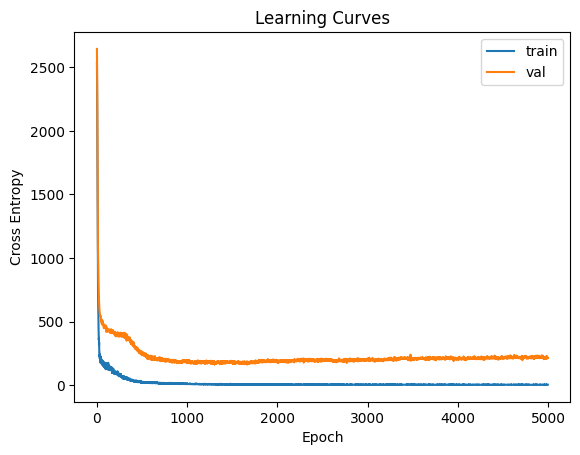

     Actual  Predicted Experiment
0     54.37  41.580219   GSE13070
1     46.00  37.752682   GSE47969
2     42.00  37.221611   GSE40551
3     44.83  36.828579   GSE13070
4     71.20  57.022518    GSE9676
..      ...        ...        ...
616   28.00  27.018934   GSE59880
617   76.09  39.347736   GSE87105
618   41.00  34.686478   GSE48278
619   53.00  35.351284   GSE48278
620   52.49  43.853142   GSE13070

[621 rows x 3 columns]


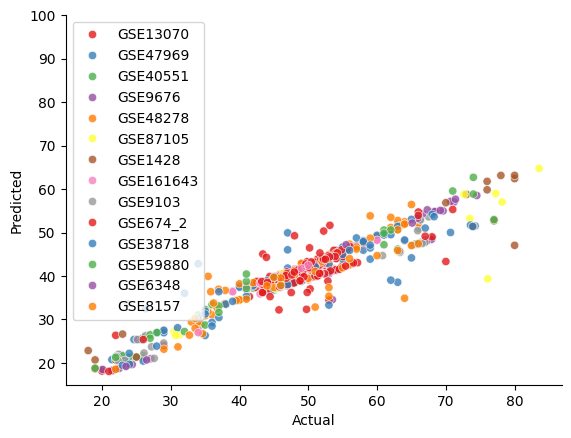

Experiment
GSE13070      230
GSE47969       96
GSE48278       93
GSE9103        28
GSE59880       24
GSE9676        24
GSE161643      21
GSE8157        19
GSE1428        18
GSE38718       16
GSE40551       15
GSE6348        13
GSE674_2       12
GSE87105       12
Name: count, dtype: int64
mae: 8.760954031706241, mse: 100.82423854753768, min: 18.070716857910156, max: 64.73974609375


In [23]:
results, error = my_model.test(normalized_X_train, my_model.y_train)
m.print_performance(my_model.history, results, my_model.z_train)

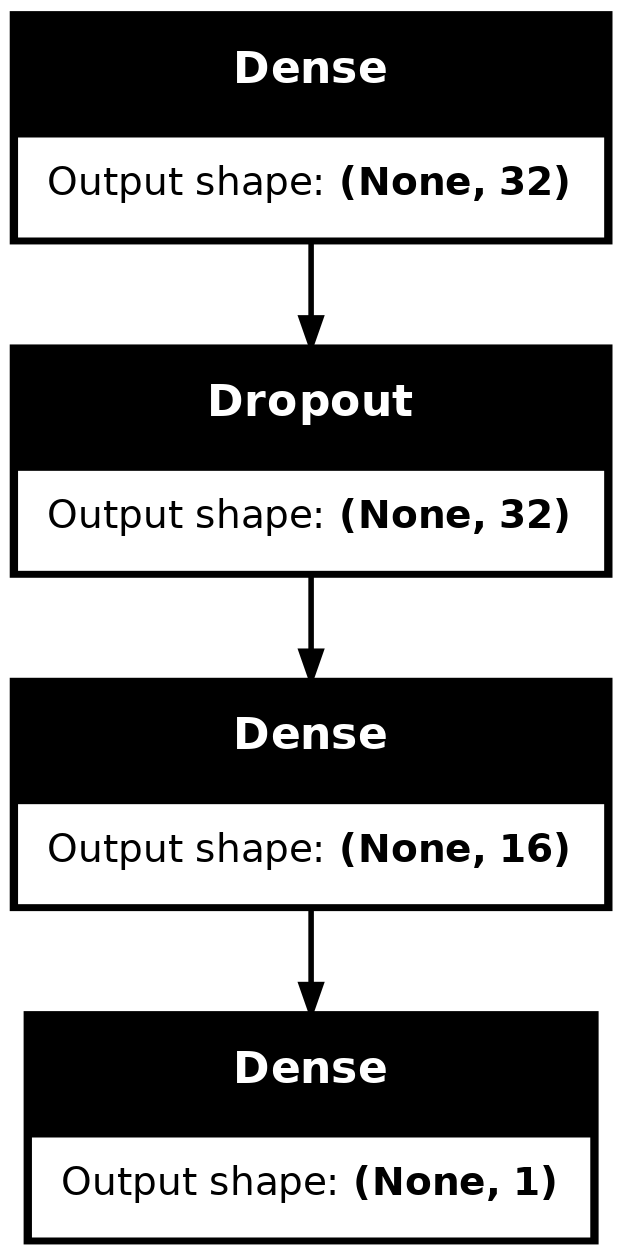

In [24]:
m.plot_model(my_model.model, 'model.png', show_shapes=True)


/tmp/ipykernel_2847/1556665160.py:3: DtypeWarning: Columns (51280) have mixed types. Specify dtype option on import or set low_memory=False.
  training_data=pd.read_csv(dataset_path)
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.736e+01, tolerance: 9.999e+00
  model = cd_fast.enet_coordinate_descent(
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MAE: 13.362
Loss: 272.095
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


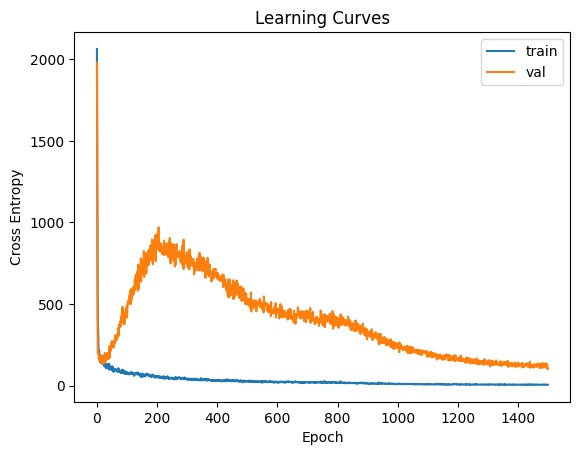

     Actual  Predicted Experiment
0     51.43  40.328316   GSE13070
1     34.20  57.263382    GSE8157
2     47.00  33.124245   GSE13070
3     39.00  37.229446   GSE47969
4     25.69  38.625290    GSE9103
..      ...        ...        ...
151   61.00  42.962448   GSE47969
152   54.15  41.924446   GSE13070
153   51.68  40.260410   GSE13070
154   46.00  25.485456   GSE48278
155   68.00  44.150917   GSE47969

[156 rows x 3 columns]


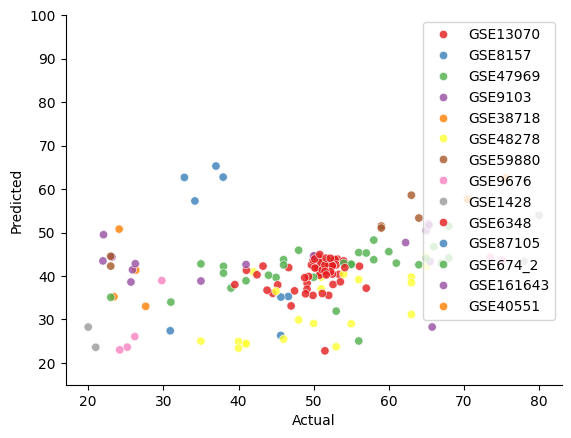

Experiment
GSE13070      50
GSE47969      29
GSE48278      21
GSE9103       12
GSE6348        7
GSE38718       6
GSE9676        6
GSE59880       6
GSE1428        4
GSE87105       4
GSE8157        4
GSE161643      3
GSE674_2       3
GSE40551       1
Name: count, dtype: int64
mae: 13.36186423179431, mse: 272.9519164147908, min: 22.789777755737305, max: 117.75647735595703
[272.09515380859375, 13.361863136291504]


In [4]:
lasso_alpha = 0.01


training_data=pd.read_csv(dataset_path)
my_model = m.Model(training_data)
normalized_X_train, normalized_X_test_fs = my_model.prepare_data(df=training_data, lasso_alpha=lasso_alpha, two_step=two_step_normalization)
my_model.train(normalize_X_train=normalized_X_train, 
                epochs=epochs, optimizer=optimizer,
                loss=loss, metrics=metrics)
m.plot_model(my_model.model, 'model.png', show_shapes=True)
results, error = my_model.test(normalized_X_test_fs, my_model.y_test)
m.print_performance(my_model.history, results, my_model.z_test)
print(error)
conf_dic = {'dataset':dataset_path,
            'loss': loss,
            'optimizer': optimizer,
            'metrics': metrics,
            'epochs': epochs, 
            'batch_size': batch_size, 
            'validation_split': validation_split, 
            'lasso_alpha': lasso_alpha, 
            'two_step_normalization': two_step_normalization}
print(conf_dic)
print(my_model.model.summary())

In [5]:
print(my_model.model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        93,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 311,045 (1.19 MB)

 Trainable params: 103,681 (405.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 207,364 (810.02 KB)

None


In [ ]:
lasso_alpha = 0.01


training_data=pd.read_csv(dataset_path)
my_model = m.Model(training_data)
normalized_X_train, normalized_X_test_fs = my_model.prepare_data(df=training_data, lasso_alpha=lasso_alpha, two_step=two_step_normalization)
my_model.train(normalize_X_train=normalized_X_train, 
                epochs=epochs, optimizer=optimizer,
                loss=loss, metrics=metrics)
m.plot_model(my_model.model, 'model.png', show_shapes=True)
results, error = my_model.test(normalized_X_test_fs, my_model.y_test)
m.print_performance(my_model.history, results, my_model.z_test)
print(error)
conf_dic = {'dataset':dataset_path,
            'loss': loss,
            'optimizer': optimizer,
            'metrics': metrics,
            'epochs': epochs, 
            'batch_size': batch_size, 
            'validation_split': validation_split, 
            'lasso_alpha': lasso_alpha, 
            'two_step_normalization': two_step_normalization}
print(conf_dic)
print(my_model.model.summary())

In [ ]:

#my_model.model = load_model('model.keras')


In [14]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
def train_data(X_train, y_train, optimizer='adam', loss='mse', metrics=['mae'], epochs=1500):
    """
    Train the data
    
    :return: The trained model
    """
    
    n_features = X_train.shape[1]
    new_model = Sequential()

    # Add layers to the model 
    
    #new_model.add(Dense(254, activation='sigmoid', kernel_initializer='he_normal', input_shape=(n_features,)))
    #new_model.add(Dropout(0.75))  # Adding dropout to reduce overfitting
    #new_model.add(Dense(128, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
    #new_model.add(Dropout(0.5))  # Adding dropout to reduce overfitting
    new_model.add(Dense(32, activation='relu', kernel_initializer='he_normal'))
    new_model.add(Dropout(0.5))  # Adding dropout to reduce overfitting
    new_model.add(Dense(16, activation='relu', kernel_initializer='he_normal'))
    new_model.add(Dense(1))

    # Compile the model
    new_model.compile(optimizer=optimizer, loss=loss, metrics=metrics)


    new_model_history= new_model.fit(X_train, y_train, epochs=epochs, batch_size=50, verbose=0, validation_split=0.1)
    return new_model, new_model_history

In [15]:
m.train_data = train_data

In [16]:
epochs = 5000

In [17]:
my_model.train(normalize_X_train=normalized_X_train, 
                epochs=epochs, optimizer=optimizer,
                loss=loss, metrics=metrics)

MAE: 22.969
Loss: 671.198
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


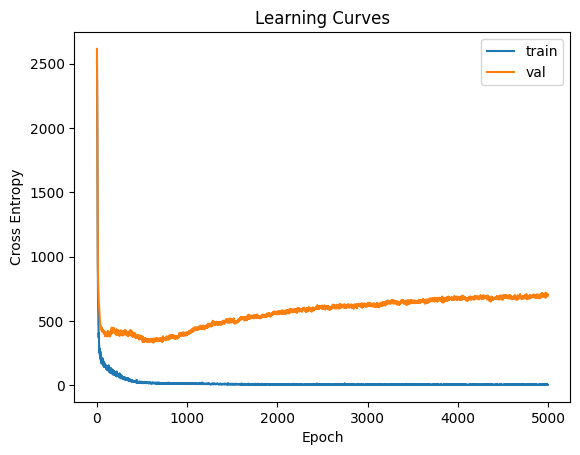

     Actual  Predicted Experiment
0     51.43  23.659521   GSE13070
1     34.20  30.414782    GSE8157
2     47.00  23.283310   GSE13070
3     39.00  35.581768   GSE47969
4     25.69  19.231054    GSE9103
..      ...        ...        ...
151   61.00  25.252026   GSE47969
152   54.15  39.219280   GSE13070
153   51.68  21.847494   GSE13070
154   46.00  25.293589   GSE48278
155   68.00  27.499226   GSE47969

[156 rows x 3 columns]


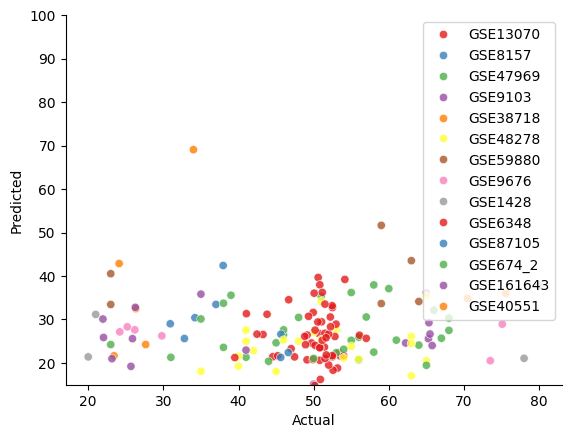

Experiment
GSE13070      50
GSE47969      29
GSE48278      21
GSE9103       12
GSE6348        7
GSE38718       6
GSE9676        6
GSE59880       6
GSE1428        4
GSE87105       4
GSE8157        4
GSE161643      3
GSE674_2       3
GSE40551       1
Name: count, dtype: int64
mae: 22.96857074493017, mse: 671.0853215602668, min: 14.811279296875, max: 69.05492401123047
[671.1981811523438, 22.968570709228516]


In [18]:
m.plot_model(my_model.model, 'model.png', show_shapes=True)
results, error = my_model.test(normalized_X_test_fs, my_model.y_test)
m.print_performance(my_model.history, results, my_model.z_test)
print(error)


MAE: 19.488
Loss: 457.135
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 722us/step


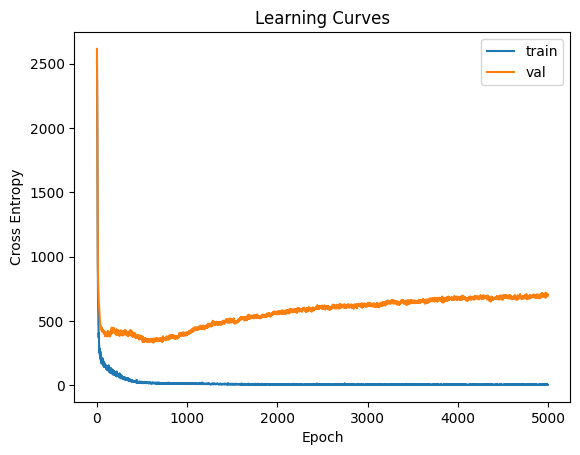

     Actual  Predicted Experiment
0     54.37  29.662565   GSE13070
1     46.00  25.708864   GSE47969
2     42.00  26.159410   GSE40551
3     44.83  25.252348   GSE13070
4     71.20  37.379601    GSE9676
..      ...        ...        ...
616   28.00  23.007818   GSE59880
617   76.09  17.536280   GSE87105
618   41.00  18.404179   GSE48278
619   53.00  28.241570   GSE48278
620   52.49  33.680702   GSE13070

[621 rows x 3 columns]


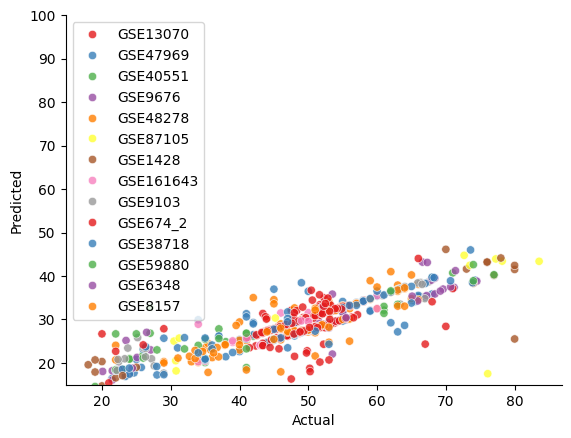

Experiment
GSE13070      230
GSE47969       96
GSE48278       93
GSE9103        28
GSE59880       24
GSE9676        24
GSE161643      21
GSE8157        19
GSE1428        18
GSE38718       16
GSE40551       15
GSE6348        13
GSE674_2       12
GSE87105       12
Name: count, dtype: int64
mae: 19.487502262772765, mse: 446.6433283605673, min: 14.585735321044922, max: 46.1330680847168


In [19]:
results, error = my_model.test(normalized_X_train, my_model.y_train)
m.print_performance(my_model.history, results, my_model.z_train)

In [12]:
results, error = my_model.test(my_model.X_train, my_model.y_train)


InvalidArgumentError: Graph execution error:

Detected at node sequential_1_1/dense_4_1/Relu defined at (most recent call last):
  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main

  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code

  File "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/usr/lib/python3.10/asyncio/base_events.py", line 603, in run_forever

  F

In [ ]:
m.print_performance(my_model.history, results, my_model.z_train)

In [ ]:
my_model.z_train[['Experiment']].value_counts()

In [ ]:
my_model.scaler.get_variable_value(train_data.columns[0])

In [ ]:
training_data[training_data["Experiment"]=="GSE1428"]

In [ ]:
results = m.evaluate_model(my_model.model, normalized_X_test_fs, my_model.y_test)

In [ ]:
results["Experiment"] = my_model.z_test["Experiment"].values
results["Sample"] = my_model.z_test["Sample"].values
results["Sex"] = my_model.z_test["Sex"].values
results["Status"] = my_model.z_test["Status"].values

results["absolute_error"] = abs(results["Actual"]-results["Predicted"])
results["big_absolute_error"] = np.where(results["absolute_error"] < 5, 0, results["absolute_error"])
results

In [ ]:
results["absolute_error"].describe()

In [ ]:
er.evaluate_error_experiment(results)



In [ ]:
er.evaluate_Kruskal_Wallis(results)

In [ ]:

er.plot_Dunes_result(er.evaluate_Dunnes_test(results))

In [ ]:

er.evaluate_grup_all_test(results)

In [ ]:


# Assuming your DataFrame is called df
formula = 'absolute_error ~ Experiment'
model = ols(formula, data=results).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table

In [ ]:
formula = 'absolute_error ~ Sex'
model = ols(formula, data=results).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table

In [ ]:
formula = 'big_absolute_error ~ Experiment'
model = ols(formula, data=results).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table

In [ ]:
from scipy.stats import kruskal

# Assuming your DataFrame is called df
# Group absolute_error by Experiment
experiment_groups = [group["absolute_error"] for name, group in results.groupby("Experiment")]

# Perform Kruskal-Wallis H-test
h_statistic, p_value = kruskal(*experiment_groups)

print("Kruskal-Wallis H-test:")
print("H-statistic:", h_statistic)
print("p-value:", p_value)

In [ ]:
import scikit_posthocs as sp



# Perform Dunn test as post-hoc analysis
dunn_results = sp.posthoc_dunn(results, val_col='absolute_error', group_col='Experiment', p_adjust='holm')
dunn_results

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming dunn_results contains the results of the Dunn test

# Generate heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(dunn_results, annot=True, cmap="YlGnBu", fmt=".3f", cbar=True)

# Set title and labels
plt.title("Dunn Test Results - Adjusted p-values")
plt.xlabel("Experiment")
plt.ylabel("Experiment")

# Show plot
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming dunn_results contains the adjusted p-values from the Dunn test

# Generate boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(data=results, x="Experiment", y="absolute_error")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Set title and labels
plt.title("Distribution of Absolute Error by Experiment")
plt.xlabel("Experiment")
plt.ylabel("Absolute Error")
plt.axhline(y=10, color='r', linestyle='--')

# Show plot
plt.show()

In [ ]:
results["Status"].unique()

In [ ]:
my_model.get_feature_weigths()


In [ ]:
my_model.feature_importance

In [ ]:
final_genes = m.get_final_selected_genes(pd.DataFrame(my_model.X_train), my_model.selector, my_model.feature_importance)
weigths = [x for x in my_model.lasso.coef_ if x != 0]
df_feature_importance = pd.DataFrame({'Gene': final_genes, 'Weigth': weigths})
df_feature_importance.iloc[df_feature_importance['Weigth'].abs().argsort()[::-1]]


In [ ]:
df_feature_importance.iloc[df_feature_importance['Weigth'].abs().argsort()[::-1]][:15]


In [ ]:
df_feature_importance.to_csv('Results/feature_importance.csv', index=False)

In [ ]:
results["absoulte_error"] = abs(results["Actual"]-results["Predicted"])

In [ ]:
my_model.model.save('model.keras')

In [ ]:
highest_mistake = results[results["absoulte_error"]>13.21]
m.plot_results(highest_mistake, highest_mistake, print_label="Experiment")

In [ ]:
results, error = my_model.test(normalized_X_test_fs, my_model.y_test)
results["absoulte_error"] = abs(results["Actual"]-results["Predicted"])
highest_mistake = results[results["absoulte_error"]>13.21]


In [ ]:
highest_mistake["Status"]= my_model.z_test["Status"]

In [ ]:
m.plot_results(highest_mistake, highest_mistake, print_label="Status")

In [ ]:
highest_sucess = results[results["absoulte_error"]<4]
m.plot_results(highest_sucess, highest_sucess, print_label="Experiment")

In [ ]:
m.plot_results(results=results, labels=my_model.z_test, print_label="Status")
results_extra = pd.concat([results, my_model.z_test], axis=1)

In [ ]:
results

In [ ]:
highest_mistake = results[results["absoulte_error"]>10]


In [ ]:
highest_mistake[['Experiment']].value_counts()

In [ ]:
high_mistake_experiments = highest_mistake[['Experiment']].value_counts().index
high_mistake_experiments_a = results[['Experiment']].value_counts()[high_mistake_experiments]
high_mistake_experiments_b = highest_mistake[['Experiment']].value_counts()

In [ ]:
experiment_sucess=pd.DataFrame({'Total': high_mistake_experiments_a, 'Mistakes': high_mistake_experiments_b, 'Ratio': high_mistake_experiments_b/high_mistake_experiments_a})

In [ ]:
experiment_sucess

his function performs a one-sided binomial test for the null hypothesis that the probability of success (in this case, making a mistake) is the same for all experiments.

In [ ]:
from scipy.stats import binom, binomtest

In [ ]:

# Calculate p-value for each row
experiment_sucess['p_value'] = experiment_sucess.apply(lambda row: binomtest(row['Mistakes'], row['Total']).pvalue, axis=1)


In [ ]:
experiment_sucess

In [ ]:
results, error = my_model.test(normalized_X_test_fs, my_model.y_test)
m.plot_results(results, my_model.z_test)

In [ ]:
m.plot_model(my_model.model, to_file='model.png', show_shapes=True)

In [ ]:
import matplotlib.pyplot as plt
#plt.hist(training_data["Age"], bins=20,orientation='vertical')
plt.bar(training_data["Experiment"].value_counts().index, training_data["Experiment"].value_counts())
plt.xticks(rotation=45)


In [ ]:
len(training_data["Experiment"].unique())

In [ ]:
plt.hist(my_model.z_train["Age"], bins=20)


In [ ]:
plt.bar(my_model.z_train["Experiment"].value_counts().index, my_model.z_train["Experiment"].value_counts())
plt.xticks(rotation=45)

In [ ]:
plt.hist(my_model.z_test["Age"], bins=20)


In [ ]:
#plt.hist(my_model.z_test["Experiment"], bins=20,orientation='horizontal')
plt.bar(my_model.z_test["Experiment"].value_counts().index, my_model.z_test["Experiment"].value_counts())
plt.xticks(rotation=45)

In [ ]:
my_model.model.summary()

I will see how was with the training data

In [ ]:
train_result, error = my_model.test(normalized_X_train, my_model.y_train)
m.print_performance(my_model.history, train_result, my_model.z_train)